# Pytorch 개발 Process

1. **데이터 준비**
    - Dataset 준비
    - Dataloader 생성

2. **입력과 출력을 연결하는 Layer(층)으로 이뤄진 네트워크(모델)을 정의**
    - **Sequential 방식**: 순서대로 쌓아올린 네트워크로 이뤄진 모델을 생성하는 방식
        - layer를 순서대로 쌓은 모델을 구현할때 간단히 모델을 정의할 수 있다.
        - layer block을 정의하는데 사용할 수 있다.
        - 생각하는 그 multi-layer 방식

    - **Subclass 방식**: 네트워크를 정의하는 클래스를 구현.
        - 다양한 구조의 모델을 정의할 수 있다.
        - inializer에서 필요한 layer들을 생성한다.
        - forward(self, X) 메소드에 forward propagation 계산을 구현한다.
        - 클래스를 정의하여 각각의 단계, **연산흐름**을 다채롭게 구성하는 방식

3. **train**
    - train 함수, test 함수 정의

4. test set 최종평가

# MNIST 이미지 분류 
- **[MNIST](https://ko.wikipedia.org/wiki/MNIST_%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B2%A0%EC%9D%B4%EC%8A%A4) (Modified National Institute of Standards and Technology) database**
- 흑백 손글씨 숫자 0-9까지 10개의 범주로 구분해놓은 데이터셋
- 하나의 이미지는 28 * 28 pixel 의 크기
- 6만개의 Train 이미지와 1만개의 Test 이미지로 구성됨.

## import

In [22]:
import torch
import torch.nn as nn  # 다양한 layer/모델 들이 정의된 패키지. (Neural Network)
from torch.utils.data import DataLoader # DataLoader 클래스 -> 모델에 데이터들을 제공하는 역할.
# 데이터를 불러와주는 아이가 왜 추가로 필요하지?
from torchvision import datasets, transforms # cf) sklearn.datasets
# torchvision 패키지(라이브러리): pytorch의 영상 전용 subpackage
## datasets(모듈): Vision(영상)관련 공개 데이터셋들을 제공하는 모듈
## transforms: 영상 데이터 전처리 기능들을 제공하는 모듈

import matplotlib.pyplot as plt

### device 설정

In [23]:
# 어느 Device에서 연산처리를 할지 지정. (cpu, cuda(GPU))
# device = "cpu"
print(torch.cuda.is_available())  # cuda를 사용할 수있는 환경인지 조회
device = "cuda" if torch.cuda.is_available() else "cpu" # 2.0이전: torch.Device("cuda")
print(device)

False
cpu


In [24]:
# MAC OS  ("cpu", "mps")
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(device)

cpu


### 하이퍼파라미터, 변수 설정

In [25]:
lr = 0.001 # 학습률. 0 ~ 1 실수. 
batch_size = 256  # 모델이 학습할 때 한 번에 몇 개씩 모델에 제공할지 개수. 
### 딥러닝의 경우 방대한 양의 데이터를 학습해야하기에 batch 라는 개념을 사용 
epochs = 20
# step: 모델의 파라미터들을 update하는 단위.
#  - 1 step: batch_size(256)개수의 데이터로 파라미터를 한번 update한 것.
# epoch: train set 전체를 학습하는 단위. 
#  - 1 epoch: 전체 데이터를 한번 다 학습한 것.

In [26]:
import os
# 학습이 끝난 모델을 저장할 디렉토리.
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)
# Dataset을 저장할 디렉토리
dataset_dir = "datasets/mnist"
os.makedirs(dataset_dir, exist_ok=True)

### MNIST dataset Loading

#### Dataset

In [27]:
### ToTensor()의 처리 
# 1) img -> ndarray 변환
# 2) 색 지정 종류를 알려주는 channel 값을 가장 앞으로 빼줌 -> pytorch.... 
# 3) Scaling 까지 
from torchvision import datasets # torchvision에서 읽어야해 visiondata잖아아
trainset = datasets.MNIST(
    root=dataset_dir, # Dataset을 읽어올 디렉토리.
    download=True,    # root 에 dataset이 없을 경우 다운로드 받을지 여부.
    transform=transforms.ToTensor()
)
testset = datasets.MNIST(
    root=dataset_dir,
    download=True,
    train=False,       # Trainset인지 여부. True(default): train set, False: test set
    transform=transforms.ToTensor()
)
######################################################################################
#  transform=함수 -> input data를 전처리하는 함수를 전달.
######################################################################################
# transforms.ToTensor 가 하는 처리
## ndarray, PIL.Image 객체를 torch.Tensor 로 변환.
## (height, width, channel) 순서를 channel first (channel, height, width) 형태로 변환.
## pixcel값들(0~255 정수)을 0 ~ 1 로 정규화. (Feature Scaling - MinMaxScaling)

In [28]:
testset

Dataset MNIST
    Number of datapoints: 10000
    Root location: datasets/mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

In [29]:
# 개별데이터 조회
trainset[0]  # tuple: (input, output)

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [30]:
trainset[0][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [31]:
import numpy as np
a = np.array(trainset[0][0])  # PIL.Image -변환-> ndarray
print(a.shape, a.dtype)
a.min(), a.max()

(1, 28, 28) float32


C:\Users\jinhy\AppData\Local\Temp\ipykernel_1328\3141442002.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = np.array(trainset[0][0])  # PIL.Image -변환-> ndarray


(np.float32(0.0), np.float32(1.0))

In [32]:
from torchvision import transforms
################ transforms.ToTensor() 적용 후 확인################
f1 = trainset[0][0]
print(f1.shape)  # (1:channel-grayscale, 28: height, 28:width)
print(f1.dtype, f1.type())
print(f1.min(), f1.max())
f1[0].size()

torch.Size([1, 28, 28])
torch.float32 torch.FloatTensor
tensor(0.) tensor(1.)


torch.Size([28, 28])

60000
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0

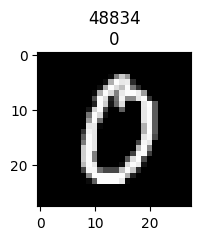

In [33]:
# ndarray로 표기할 경우, squeeze를 통해 더미축을 제거해주어야 한다. 
import random
print(len(trainset))
idx = random.randint(0, len(trainset)) #0 ~ 60000 사이 랜덤 정수를 반환.
img, label = trainset[idx] # (input img, output) 꼴 반환 
print(img)
plt.figure(figsize=(2, 2))
plt.imshow(img.squeeze(), cmap="gray") # (1, 28, 28) -> (28, 28). matplotlib은 이미지를 (h, w, c) 로 전달해야함. ? squeeze 할필요 없는디? 할수도 없고 
plt.title(f"{idx}\n{label}")
plt.show()

#### DataLoader

In [34]:
from torch.utils.data import DataLoader
# DataLoader: Dataset의 데이터들을 모델에 제공하는 역할. 데이터들을 모델에 어떻게 제공할지 설정해서 생성.
# -> Dataset(tensor처럼 .data 외에도 여러 속성가짐), Tensor, ndarray 등 많은 자료형을 받음.
# Dataset: 데이터들을 가지고 있는 역할. 하나씩 조회하는 기능을 제공.
### why needed? batch 뽑아줄 사람 ! 
train_loader = DataLoader(
    trainset,              # Dataset, 튜플 형식 
    batch_size=batch_size, # batch size (256)
    shuffle=True,   # 모델에 데이터를 제공하기 전에 섞을지 여부. (default: False) True: 한 epoch 학습 전에 섞는다. -> 한바퀴 돌았으면 batch 새롭게 짜야지 ! 
    drop_last=True, # 모델에 제공할 데이터의 개수가 batch_size보다 적으면 제공하지 않는다. (학습에 사용안함)
)

test_loader = DataLoader(testset, batch_size=batch_size)
# Test의 경우 셔플 여부 중요 X | 자투리까지 테스트 해봐야해 

In [35]:
# 전체 데이터 개수.
len(trainset), len(testset)

(60000, 10000)

In [36]:
# 1 epoch 당 step 수 조회. -> drop_last 여부에 따라 달라져 
print(len(train_loader), len(test_loader))

234 40


### 모델 정의

In [37]:
# subclass(상속) 방식
## - nn.Module 상속한 클래스를 정의.
## - __init__(): 입력값을 추론(순전파 연산)하는데 필요한 layer객체들을 생성.  |  앞으로 사용할 Layer 객체들 
## - forward(): __init__() 에서 생성한 layer들을 이용해 연산 로직을 정의  |  Forward 메소드 정의 

In [38]:
import torch.nn as nn
# nn.Module.train() : 학습 모드 설정
# nn.Module.eval() : 평가 모드 설정 
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()  # 상위클래스 nn.Module 을 초기화.
        
        # Linear(input feature 개수, output feature 개수)
        # 아래 Layer 별 Feature 개수는 데이터를 보고 감으로 때려 맞춰 ~ 
        self.lr1 = nn.Linear(784, 128) # (784:(28*28): MNIST 이미지의 pixcel수, 출력: 128)
        self.lr2 = nn.Linear(128, 64)  # (128: lr1의 출력개수, 출력: 64)
        self.lr3 = nn.Linear(64, 32)   # (64:  lr2의 출력개수, 출력: 32)
        self.lr4 = nn.Linear(32, 10)   # (32:  lr3의 출력개수, 출력: 10)
        # 마지막 Linear()의 출력 개수(10) - 분류할 class개수(0 ~ 9)

    def forward(self, X):
        """
        X를 입력 받아서 y를 추론하는 계산로직을 정의
        initializer에서 정의한 Linear들을 이용해서 계산.
        Args:
            X(torch.FloatTensor) - 추론할 MNIST 이미지들. shape: (batch_size, 1, 28, 28)
        """
        # (batch_size, 1, 28, 28) 를 (batch_size, 784) feature들을 1차원으로 변환.
        X = torch.flatten(X, start_dim=1) # 다차원 배열을 1차원 배열로 변환. (start_dim=1, Flatten 시킬 시작 axis지정. 0축은 놔두고 1축 부터 flatten시킨다.)
        X = self.lr1(X)  # Linear: 선형함수 / 그래서 flatten 필요 
        X = nn.ReLU()(X) # Activation(활성) 함수. 비선형함수. ReLU(x): max(x, 0)
        
        X = self.lr2(X)
        X = nn.ReLU()(X)
        
        X = self.lr3(X)
        X = nn.ReLU()(X)
        
        output = self.lr4(X)
        return output

In [39]:
'''ReLU 함수
    Input Feature들의 선형결합을 통해 Ouput Feature를 예상하는 nn.Linear 특성 상
특징들의 비선형적인 관계를 전혀 반영하지 못하므로 이를 어떻게든 반영시켜주기 위한 활성함수.
    양수 부분에 대해 기울기를 1로 유지하므로 '기울기 소실' 문제를 해결할 수 있으며 max(0, x)를 통해
빠른 계산이 가능하다. 반면, 음수 부분의 기울기를 죽이므로 일부 뉴런의 비활성화 효과를 기대할 수 있으며
이를 통해 비선형성을 획득할 수 있다.
+) Sigmoid 함수의 경우 많은 값에 대해 기울기가 아주 작은 값을 가지므로 gradient가 점점점점 작아져버리는 현상이 나타남
    음수 가중합을 가지는 뉴런을 다 죽이는 것이 맞느냐?
-> 단점은 맞지만 비선형성을 추가해주는 밸류가 더 높다 이거야 ~! 
'''

"ReLU 함수\n    Input Feature들의 선형결합을 통해 Ouput Feature를 예상하는 nn.Linear 특성 상\n특징들의 비선형적인 관계를 전혀 반영하지 못하므로 이를 어떻게든 반영시켜주기 위한 활성함수.\n    양수 부분에 대해 기울기를 1로 유지하므로 '기울기 소실' 문제를 해결할 수 있으며 max(0, x)를 통해\n빠른 계산이 가능하다. 반면, 음수 부분의 기울기를 죽이므로 일부 뉴런의 비활성화 효과를 기대할 수 있으며\n이를 통해 비선형성을 획득할 수 있다.\n+) Sigmoid 함수의 경우 많은 값에 대해 기울기가 아주 작은 값을 가지므로 gradient가 점점점점 작아져버리는 현상이 나타남\n    음수 가중합을 가지는 뉴런을 다 죽이는 것이 맞느냐?\n-> 단점은 맞지만 비선형성을 추가해주는 밸류가 더 높다 이거야 ~! \n"

### Train

#### 모델, loss function, optimizer 생성

In [40]:
# 모델객체 생성
model = MNISTModel()
# 확인
print(model)

MNISTModel(
  (lr1): Linear(in_features=784, out_features=128, bias=True)
  (lr2): Linear(in_features=128, out_features=64, bias=True)
  (lr3): Linear(in_features=64, out_features=32, bias=True)
  (lr4): Linear(in_features=32, out_features=10, bias=True)
)


In [41]:
# Loss함수 - 학습 할 때 모델이 예측한 값과 정답간의 오차를 계산하는 함수. 이 오차를 줄이는 방향으로 파라미터를 변경한다.
# 다중 분류 문제의 Loss함수: crossentropyloss함수. (이진분류: binary crossentropy, 회귀: mse)
loss_fn = nn.CrossEntropyLoss()  # torch.nn.functional.cross_entropy 함수사용도 가능.

In [42]:
lr = 0.0001
# optimizer 정의: 모델의 파라미터들을 업데이트하고 파라미터들의 gradient값을 초기화 한다.
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#### 학습(훈련-train) 및 검증

In [43]:
# 학습시 계산에 사용되는 값들은 같은 device(cpu or cuda or mps)에 있어야 한다
## device로 이동할 대상: Model객체, X(input), y(output)

In [44]:
model = MNISTModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [45]:
import time
# 학습
## 에폭별 검증결과들을 저장할 리스트
train_loss_list = []
valid_loss_list = []
valid_acc_list = []
s = time.time()

# 학습-중첩 반복문: epoch 반복 -> step(batch_size) 에 대한 반복
for epoch in range(epochs):
    ###############################################
    # 모델 Train - 1 epoch : Trainset
    ###############################################
    model.train()  # 모델을 train 모드로 변환.
    train_loss = 0 # 현재 epoch의 train loss를 저장할 변수.

    # batch 단위로 학습: 1 step - 1개 batch의 데이터로 학습.
    for X_train, y_train  in train_loader: # 한번 반복할 때마다 1개 batch 데이터를 순서대로 제공. (X, y) 를 묶어서 제공한다.
        # DataLoader는 전체 데이터를 각 batch size에 맞게 전달해주는 아이야. 

        # 1. X, y를 devcie로 이동
        X_train, y_train = X_train.to(device), y_train.to(device)
        # 2. 모델을 이용해 추론 | batch를 넣어줘 
        pred = model(X_train) # Model.forward(X_train) 메소드 호출
        # 3. loss 계산 
        loss = loss_fn(pred, y_train)
        # 4. gradient 계산
        loss.backward()
        # 5. 모델의 파라미터들(weight, bias) update
        optimizer.step()
        # 6. gradient 초기화
        optimizer.zero_grad()
        # 학습 결과 저장및 출력을 위해 loss 저장.
        train_loss = train_loss + loss.item() 

    
    train_loss = train_loss / len(train_loader)  # 한 에폭에서 학습한 step별 loss의 평균계산.
    train_loss_list.append(train_loss)
    
    ###############################################
    # 1 epoch 학습한 결과 검증: Testset
    ###############################################
    model.eval()  # 모델을 evaluation() (추론, 검증) 모드로 변환.
    # 이것도 epoch 별 valid_set의 loss와 acc 기록 
    valid_loss = 0
    valid_acc = 0
    with torch.no_grad(): # 추론만 함 -> gradient 계산할 필요 없음. -> grad_fn 구할 필요없다.  |  eval 모드면 안써줘도 돼 
        for X_valid, y_valid in test_loader:
            # 1. device 로 이동
            X_valid, y_valid = X_valid.to(device), y_valid.to(device)
            # 2. 추론
            pred_valid = model(X_valid)
            # 3-1. 검증 -> loss 계산
            valid_loss = valid_loss + loss_fn(pred_valid, y_valid).item()
            # 3-2. 검증 -> accuracy 계산
            ## pred_valid shape: (256, 10: class별 확률) -> 정답 class 추출
            pred_valid_class = pred_valid.argmax(dim=-1) # index가 곧 class 여기서는..
            valid_acc = valid_acc + torch.sum(y_valid == pred_valid_class).item()
        
        # 검증결과 누적값의 평균
        valid_loss = valid_loss / len(test_loader)  # loss는 step수 나눔.
        valid_acc = valid_acc / len(testset)        # accuracy는 데이터 개수로 나눔.
        valid_loss_list.append(valid_loss)
        valid_acc_list.append(valid_acc)

        # 검증 결과 출력
        print(f"[{epoch+1:02d}/{epochs}] train_loss: {train_loss}, valid_loss: {valid_loss}, valid_acc: {valid_acc}")

e = time.time()
print('학습에 걸린 시간(초):', e-s)

[01/20] train_loss: 1.9137141587387803, valid_loss: 1.202086253464222, valid_acc: 0.7283
[02/20] train_loss: 0.7753496561040226, valid_loss: 0.5340720098465681, valid_acc: 0.8541
[03/20] train_loss: 0.47801496266809285, valid_loss: 0.4078271508216858, valid_acc: 0.8862
[04/20] train_loss: 0.3906466442550349, valid_loss: 0.3503206863999367, valid_acc: 0.8998
[05/20] train_loss: 0.3464997322895588, valid_loss: 0.3207467135973275, valid_acc: 0.9066
[06/20] train_loss: 0.31886916104544943, valid_loss: 0.2972937786951661, valid_acc: 0.9138
[07/20] train_loss: 0.2985958756926732, valid_loss: 0.2817033142782748, valid_acc: 0.9181
[08/20] train_loss: 0.2825974078896718, valid_loss: 0.26730850343592466, valid_acc: 0.9213
[09/20] train_loss: 0.2685229320429329, valid_loss: 0.2566186418756843, valid_acc: 0.9252
[10/20] train_loss: 0.256320015169107, valid_loss: 0.24654697701334954, valid_acc: 0.9274
[11/20] train_loss: 0.24534564516228488, valid_loss: 0.23720460534095764, valid_acc: 0.9315
[12/20

#### 학습 로그 시각화

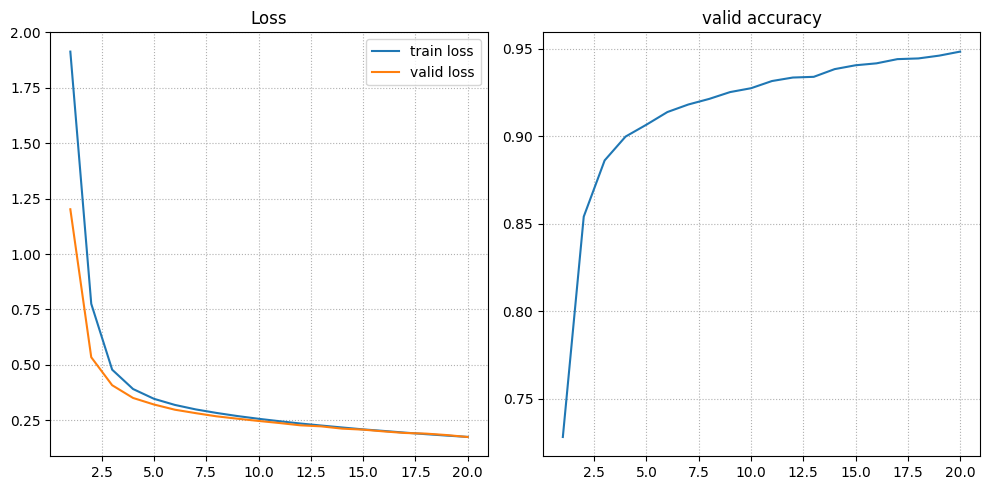

In [47]:
import matplotlib.pyplot as plt
# train loss, valid loss, valid acc 를 epoch 별로 어떻게 변하는지 시각화.
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_loss_list, label="train loss")
plt.plot(range(1, epochs+1), valid_loss_list, label="valid loss")
plt.title("Loss")
plt.legend()
plt.grid(True, linestyle=":")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), valid_acc_list)
plt.title("valid accuracy")

plt.tight_layout()
plt.grid(True, linestyle=":")
plt.show()


### 학습된 모델 저장 및 불러오기

In [48]:
import os
saved_dir = "models"
os.makedirs(saved_dir, exist_ok=True)

save_path = os.path.join(saved_dir, "mnist_model.pt")
save_path

'models\\mnist_model.pt'

In [49]:
import torch 
# 모델 저장: 파일 확장자 - pt, pth
torch.save(model, save_path)  #  (저장할 모델, 저장할 파일 경로)

In [51]:
# 저장된 모델 load(불러오기)
load_model = torch.load(save_path, weights_only=False)
print(load_model)

MNISTModel(
  (lr1): Linear(in_features=784, out_features=128, bias=True)
  (lr2): Linear(in_features=128, out_features=64, bias=True)
  (lr3): Linear(in_features=64, out_features=32, bias=True)
  (lr4): Linear(in_features=32, out_features=10, bias=True)
)


## 모델 성능 최종 평가

In [52]:
load_model = load_model.to(device)
load_model.eval() # 평가모드

test_loss = test_acc = 0
with torch.no_grad():
    for X_test, y_test in test_loader:
        # device 이동
        X_test, y_test = X_test.to(device), y_test.to(device)
        # 추론
        pred_test = load_model(X_test)
        # 검증 - loss
        loss_test = loss_fn(pred_test, y_test)
        test_loss += loss_test.item()
        # 검증 - accuracy
        ## class
        pred_test_class = pred_test.argmax(dim=-1)
        test_acc += torch.sum(pred_test_class == y_test).item()

    test_loss = test_loss / len(test_loader)
    test_acc = test_acc / len(testset)

In [53]:
print(test_loss, test_acc)

0.17405736017972231 0.9483


In [54]:
print(y_test.shape)
y_test

torch.Size([16])


tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6])

In [55]:
p = load_model(X_test)
p.shape

torch.Size([16, 10])

In [56]:
p_class = p.argmax(dim=-1)

In [57]:
torch.sum(y_test == p_class).item() # 맞은 것의 개수.

15

## 새로운 데이터 추론

In [58]:
from PIL import Image

def load_data(device="cpu", *path):
    """
    받은 경로의 이미지들을 읽어서 Tensor로 변환해 반환한다.

    1. 전달받은 경로의 이미지 파일들을 읽는다.
    2. 28 x 28 로 resize
    3. torch.Tensor로 변환 + 전처리
    4. devcie로 이동시킨 뒤 반환한다.
    """
    input_tensors = []
    for p in path:
        img = Image.open(p)
        img = img.convert('L')     # grayscale로 변환.
        img = img.resize((28, 28)) # 모델이 학습한 데이터 size(28, 28)로 변환.
        img = transforms.ToTensor()(img) # 객체의 메소드라서 이렇게 사용해 
        input_tensors.append(img)
        
    return torch.stack(input_tensors).to(device)

In [59]:
def predict(model, inputs, device="cpu"):
    """
    받은 model에 inputs를 추론하여 그 결과 class들을 반환한다.
    """
    with torch.no_grad():
        model = model.to(device)
        model.eval()
        pred = model(inputs)
        pred_class = pred.argmax(dim=-1)
        return pred_class

In [60]:
# glob을 이용해 테스트 이미지들의 경로 조회.
from glob import glob
file_list = glob("test_img/**/*.png")
file_list

['test_img\\num\\eight.png',
 'test_img\\num\\eight2.png',
 'test_img\\num\\five.png',
 'test_img\\num\\four.png',
 'test_img\\num\\four2.png',
 'test_img\\num\\one.png',
 'test_img\\num\\seven.png',
 'test_img\\num\\seven2.png',
 'test_img\\num\\seven3.png',
 'test_img\\num\\three.png',
 'test_img\\num\\three2.png',
 'test_img\\num\\two.png',
 'test_img\\num\\two2.png']

In [61]:
r = load_data(device, *file_list)
result_pred = predict(load_model, r)
result_pred

tensor([6, 3, 5, 4, 4, 0, 3, 3, 3, 3, 3, 2, 2])

C:\Users\jinhy\AppData\Local\Temp\ipykernel_1328\3930646809.py:12: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinhy\AppData\Local\Temp\ipykernel_1328\3930646809.py:12: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinhy\AppData\Local\Temp\ipykernel_1328\3930646809.py:12: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinhy\AppData\Local\Temp\ipykernel_1328\3930646809.py:12: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\jinhy\anaconda3\envs\dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jinhy\anaconda3\envs\dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: G

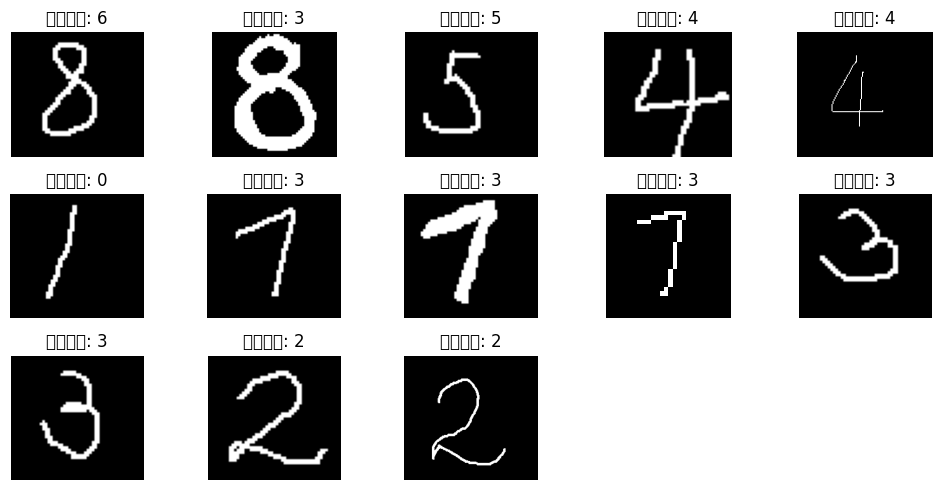

In [62]:
# 확인

plt.figure(figsize=(10, 5))
for idx, (path, label) in enumerate(zip(file_list, result_pred)):
    # print(idx, path, label, sep=" , ")
    img = Image.open(path).convert('L')
    plt.subplot(3, 5, idx+1)  #3, 4
    plt.imshow(img, cmap="gray")
    plt.title(f"예측결과: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()